# Chapter 4 — Representing Data and Engineering Features

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain why data representation affects model performance.
2. Apply one-hot encoding to categorical variables.
3. Use binning to transform continuous variables.
4. Create polynomial features for nonlinear patterns.
5. Apply feature selection to reduce irrelevant variables.

## Chapter Overview

Machine learning algorithms do not understand raw human concepts directly. They learn from numerical feature representations. Therefore, the way we encode and transform data can strongly affect model performance.

Feature engineering is the process of creating better input representations from raw data. Sometimes a simple model with good features can outperform a complex model with poor features.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. One-Hot Encoding for Categorical Variables

Categorical variables contain values such as city names, product types, or user categories. Most machine learning algorithms require numerical input, so categorical values must be converted.

One-hot encoding creates one binary column for each category. This prevents the model from assuming an artificial order between categories.

### What this code does

The code creates a small dataset with categorical columns and converts them into one-hot encoded columns using `pd.get_dummies()`.

In [2]:
data = pd.DataFrame({
    'city': ['Bandung', 'Jakarta', 'Bandung', 'Surabaya', 'Jakarta'],
    'user_type': ['new', 'returning', 'returning', 'new', 'new'],
    'transactions': [3, 10, 7, 2, 5]
})

encoded = pd.get_dummies(data, columns=['city', 'user_type'])
print('Original data:')
print(data)
print('\nOne-hot encoded data:')
print(encoded)

Original data:
       city  user_type  transactions
0   Bandung        new             3
1   Jakarta  returning            10
2   Bandung  returning             7
3  Surabaya        new             2
4   Jakarta        new             5

One-hot encoded data:
   transactions  city_Bandung  city_Jakarta  city_Surabaya  user_type_new  \
0             3          True         False          False           True   
1            10         False          True          False          False   
2             7          True         False          False          False   
3             2         False         False           True           True   
4             5         False          True          False           True   

   user_type_returning  
0                False  
1                 True  
2                 True  
3                False  
4                False  


### Output Interpretation

The original categorical columns are replaced by binary indicator columns. For example, `city_Bandung` equals 1 if the sample belongs to Bandung and 0 otherwise. This representation is suitable for many machine learning models.

## 2. Binning Continuous Features

Binning converts a continuous feature into intervals. This can help linear models represent nonlinear relationships.

### Theory

A linear model usually fits a straight line. If the real relationship is curved, the model may underfit. Binning allows the linear model to learn different constant values in different regions.

However, binning may reduce information because exact continuous values are replaced by interval membership.

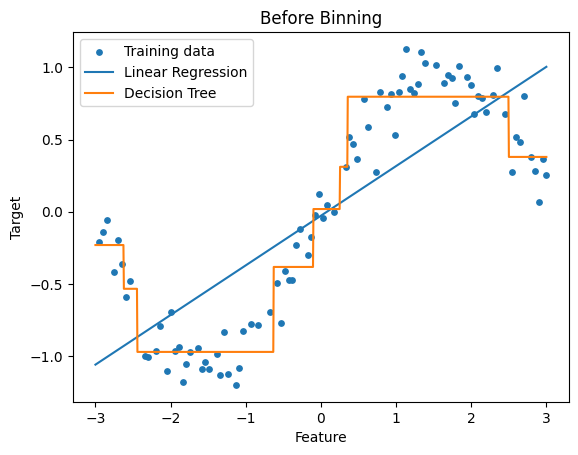

In [3]:
from sklearn.preprocessing import KBinsDiscretizer, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

rng = np.random.RandomState(RANDOM_STATE)
X = np.linspace(-3, 3, 120).reshape(-1, 1)
y = np.sin(X).ravel() + rng.normal(scale=0.15, size=120)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE)
line = np.linspace(-3, 3, 1000).reshape(-1, 1)

linear_model = LinearRegression().fit(X_train, y_train)
tree_model = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(X_train, y_train)

plt.scatter(X_train, y_train, s=15, label='Training data')
plt.plot(line, linear_model.predict(line), label='Linear Regression')
plt.plot(line, tree_model.predict(line), label='Decision Tree')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Before Binning')
plt.legend()
plt.show()

### Output Interpretation

The linear model produces a straight trend, which may not capture the sinusoidal pattern well. The decision tree can model nonlinear behavior more naturally because it splits the feature space into regions.

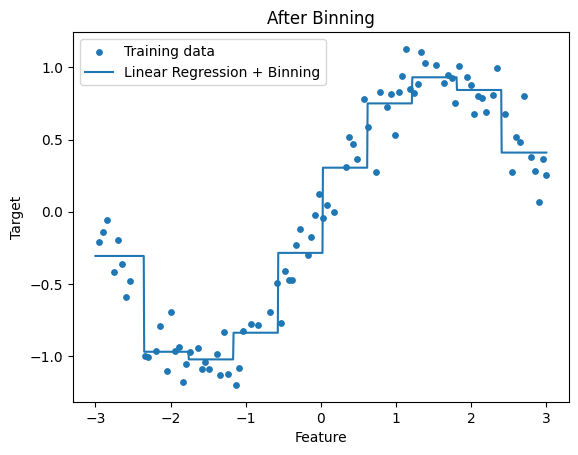

Linear model R2 before binning: 0.655
Linear model R2 after binning : 0.925


In [4]:
binner = KBinsDiscretizer(n_bins=10, encode='onehot-dense', strategy='uniform')
X_train_binned = binner.fit_transform(X_train)
line_binned = binner.transform(line)

linear_binned = LinearRegression().fit(X_train_binned, y_train)

plt.scatter(X_train, y_train, s=15, label='Training data')
plt.plot(line, linear_binned.predict(line_binned), label='Linear Regression + Binning')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('After Binning')
plt.legend()
plt.show()

print('Linear model R2 before binning:', round(linear_model.score(X_test, y_test), 3))
print('Linear model R2 after binning :', round(linear_binned.score(binner.transform(X_test), y_test), 3))

### Output Interpretation

After binning, the linear model becomes piecewise constant. This gives it more flexibility than a single straight line. The R² score helps compare whether the transformed representation improves predictive performance.

## 3. Polynomial Features

Polynomial features add powers of existing features, such as `x²`, `x³`, and so on. They allow linear models to fit nonlinear curves.

### Theory

A linear model is linear with respect to its input features. If we add nonlinear transformations of the original features, the model can still be linear in the expanded feature space while producing nonlinear predictions in the original feature space.

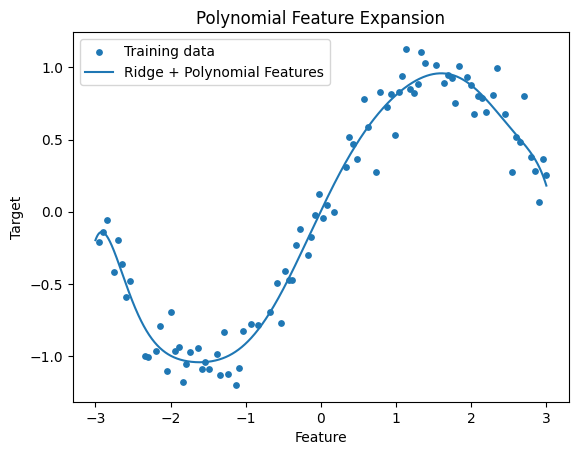

Polynomial model R2 train: 0.968
Polynomial model R2 test : 0.968


In [5]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=10, include_bias=False)),
    ('ridge', Ridge(alpha=0.01))
])

poly_model.fit(X_train, y_train)

plt.scatter(X_train, y_train, s=15, label='Training data')
plt.plot(line, poly_model.predict(line), label='Ridge + Polynomial Features')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Polynomial Feature Expansion')
plt.legend()
plt.show()

print('Polynomial model R2 train:', round(poly_model.score(X_train, y_train), 3))
print('Polynomial model R2 test :', round(poly_model.score(X_test, y_test), 3))

### Output Interpretation

Polynomial features allow the model to fit a smooth nonlinear curve. However, very high-degree polynomial features can overfit, especially near the boundaries. Ridge regularization helps control coefficient size and reduce overfitting.

## 4. Feature Selection

Feature selection removes irrelevant or weakly informative features. It can reduce overfitting, improve interpretability, and speed up training.

This example uses `SelectPercentile`, which selects a percentage of features based on statistical tests.

In [6]:
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectPercentile, f_classif

X_cls, y_cls = make_classification(
    n_samples=300,
    n_features=30,
    n_informative=5,
    n_redundant=5,
    random_state=RANDOM_STATE
)

selector = SelectPercentile(score_func=f_classif, percentile=30)
X_selected = selector.fit_transform(X_cls, y_cls)

print('Original shape:', X_cls.shape)
print('Shape after feature selection:', X_selected.shape)
print('Selected feature indices:', np.where(selector.get_support())[0])

Original shape: (300, 30)
Shape after feature selection: (300, 9)
Selected feature indices: [ 3  5  8 13 15 18 21 23 29]


### Output Interpretation

The feature matrix is reduced from 30 features to a smaller number. The selected feature indices show which columns were retained. This does not guarantee perfect performance, but it provides a simpler representation that may generalize better.

## Key Takeaways

- Data representation is often as important as algorithm choice.
- One-hot encoding is essential for categorical variables.
- Binning can help linear models handle nonlinear patterns.
- Polynomial features expand the feature space and allow nonlinear predictions.
- Feature selection can reduce noise and improve interpretability.

## Chapter Summary

Chapter 4 emphasizes that machine learning models depend heavily on feature representation. Feature engineering transforms raw data into a form that better exposes useful patterns to the model.